In [ ]:
import os 
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ['JAX_PLATFORMS'] = 'cpu'


import seqMAE
import scanpy as sc 
import numpy as np 
import matplotlib.pyplot as plt 
import json
import pandas as pd
import jax
import h5py
import pickle5 


In [18]:
BASE_DIR = "/mnt/fxcai/nfs_share2"
data_dir = f"{BASE_DIR}/scb_multiome/pbmc_10k/data"
atac_path = f"{data_dir}/atac_data/ad_atac_132k.h5ad"
rna_path = f"{data_dir}/rna_data/tfs.h5ad"
preprocess_folder_acc = f"{data_dir}/atac_data/scb_processed"
preprocess_folder_rna = f"{data_dir}/rna_data"

result_dir = "."

In [23]:
ad_atac = sc.read_h5ad(atac_path)
ad_rna = sc.read_h5ad(rna_path)

sc.pp.scale(ad_rna)

## load the model & params 

In [ ]:
with open(f"{result_dir}/config.json") as f:
    config_d = json.load(f)
    
model = seqMAE.core.scb_TFs.Model(preprocess_folder_acc = preprocess_folder_acc,
                                preprocess_folder_rna=preprocess_folder_rna,
                                atac = ad_atac.X.T,
                                rna = ad_rna.X,
                                model_config=config_d['model_config']
                                )
model.create_model()
all_ds = model.read_accrna_ds(ds_key='all')

with open(f"{result_dir}/result.pkl", "rb") as handle:
    data = pickle5.load(handle)
model.load_data(data,
                keys = ['params_all', 'y_pred', 'metrics'])

### performance (fine-tuning)

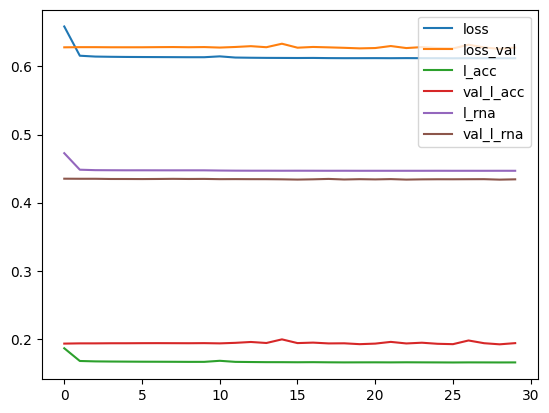

In [14]:
fig, ax = plt.subplots()
ax.plot(model.metrics['l'], label="loss")
ax.plot(model.metrics['val_l'], label="loss_val")

ax.plot(model.metrics['l_acc'], label="l_acc")
ax.plot(model.metrics['val_l_acc'], label="val_l_acc")

ax.plot(model.metrics['l_rna'], label="l_rna")
ax.plot(model.metrics['val_l_rna'], label="val_l_rna")

ax.legend();

In [5]:
## test auroc 
split_file = f"{model.preprocess_folder_acc}/splits.h5"
cell_split_file = f"{model.preprocess_folder_rna}/cell_splits.h5"
with h5py.File(split_file, 'r') as hf:
    test_ids = hf[f'test_ids'][:]
    train_ids = hf[f'train_ids'][:]

with h5py.File(cell_split_file, 'r') as hf:
    test_cell_ids = hf[f'test_ids'][:]
    train_cell_ids = hf[f'train_ids'][:]

In [ ]:
train_corr = seqMAE.utils.eval_metrics.corrcoef(all_ds['rna'][train_cell_ids].T, model.y_pred['rna'][train_cell_ids].T)
test_corr = seqMAE.utils.eval_metrics.corrcoef(all_ds['rna'][test_cell_ids].T, model.y_pred['rna'][test_cell_ids].T)
corr_df = pd.DataFrame({
    "train": [np.mean(train_corr['corr_per_cell']), np.mean(train_corr['corr_per_gene'])],
    "test": [np.mean(np.nan_to_num(test_corr['corr_per_cell'], 0)), np.mean(np.nan_to_num(test_corr['corr_per_gene'], 0))],
}, index=['pcc_per_cell', "pcc_per_gene"])
corr_df

,train,test
pcc_per_cell,0.437298,0.403641
pcc_per_gene,0.430587,0.390016


In [ ]:
## train auroc 
train_auroc = seqMAE.utils.eval_metrics.auroc(y_true=all_ds['y_acc'][train_ids][:,train_cell_ids], 
                                           y_pred=jax.nn.sigmoid(model.y_pred['acc'][train_ids][:,train_cell_ids])) 
test_auroc = seqMAE.utils.eval_metrics.auroc(y_true=all_ds['y_acc'][test_ids][:,test_cell_ids], 
                                           y_pred=jax.nn.sigmoid(model.y_pred['acc'][test_ids][:,test_cell_ids])) 

## P1 & P2
unseen_peaks_auroc = seqMAE.utils.eval_metrics.auroc(y_true=all_ds['y_acc'][test_ids][:,train_cell_ids], 
                                           y_pred=jax.nn.sigmoid(model.y_pred['acc'][test_ids][:,train_cell_ids])) 

unseen_cells_auroc = seqMAE.utils.eval_metrics.auroc(y_true=all_ds['y_acc'][train_ids][:,test_cell_ids], 
                                           y_pred=jax.nn.sigmoid(model.y_pred['acc'][train_ids][:,test_cell_ids])) 
auroc_df = pd.DataFrame({
    "train": [np.mean(np.nan_to_num(train_auroc['auroc_per_cell'], 0.5)), np.mean(np.nan_to_num(train_auroc['auroc_per_peak'], 0.5))],
    "test": [np.mean(np.nan_to_num(test_auroc['auroc_per_cell'], 0.5)), np.mean(np.nan_to_num(test_auroc['auroc_per_peak'], 0.5))],
    "unseen_peaks": [np.mean(np.nan_to_num(unseen_peaks_auroc['auroc_per_cell'], 0.5)), np.mean(np.nan_to_num(unseen_peaks_auroc['auroc_per_peak'], 0.5))],
    "unseen_cells": [np.mean(np.nan_to_num(unseen_cells_auroc['auroc_per_cell'], 0.5)), np.mean(np.nan_to_num(unseen_cells_auroc['auroc_per_peak'], 0.5))]
                         })
auroc_df.index = ["auroc_per_cell", "auroc_per_peak"]
auroc_df

,train,test,unseen_peaks,unseen_cells
auroc_per_cell,0.897785,0.824247,0.824492,0.896929
auroc_per_peak,0.730997,0.674604,0.674385,0.730083


/mnt/fxcai/nfs_share2/anaconda3/envs/demo/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


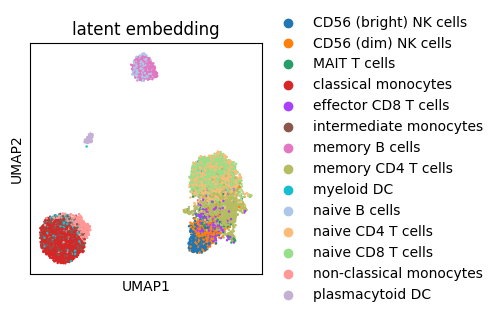

In [ ]:
ad_rna.obsm['X_umap_orig'] = ad_rna.obsm['X_umap']
cellemb = seqMAE.utils.MLP(features=model.model_config["encoder_features"],
                         batchnormalize=model.model_config["mlp_batchnorm"]).apply(
    {"params": model.state.params['MLP_0'],
     "batch_stats": model.state.batch_stats['MLP_0']},
    model.rna, 
    False)

cellemb = np.array(cellemb)

cellemb_plot = seqMAE.utils.plot_cell_embeddings(ad_rna, Z=[cellemb], keys=['latent embedding'], color_key="celltype")
os.makedirs("./figs", exist_ok=True)
plt.savefig("./figs/latent_emb.svg", dpi=300, bbox_inches='tight')

### get depth-normalized pred acc

In [6]:
all_ds_avg_dpth = all_ds.copy()
all_ds_avg_dpth['atac_dpth'] = np.repeat(np.mean(all_ds['atac_dpth'], keepdims=True,), all_ds['atac_dpth'].shape[0])
acc_pred_no_dpth = model.pred_y(n_batch=256, ds=all_ds_avg_dpth, return_res=True, save_self=False)['acc']
acc_pred_no_dpth = jax.nn.sigmoid(acc_pred_no_dpth)
np.savez("./benchmark_summarize/acc_pred_no_dpth.npz", acc_pred_no_dpth, )

100%|██████████| 257/257 [04:04<00:00,  1.05it/s]


### compute gradTF 
fix $X_{seq}$ \
$gradTF = dy_{acc}/dX_{rna}$ \
gradTF is of shape (n_peak, n_cell, n_tf)

In [19]:
os.makedirs("./benchmark_summarize", exist_ok=True)

In [25]:
## Since gradTF is very large, subset peaks to >=10% acc 

print(ad_atac.shape)
peaks_select = ad_atac.var['n_cells']>0.1*ad_atac.n_obs
acc_pred_no_dpth = np.load("./benchmark_summarize/acc_pred_no_dpth.npz")['arr_0']
acc_pred_no_dpth_df = pd.DataFrame(acc_pred_no_dpth, index=ad_atac.var.index, columns=ad_atac.obs.index)
acc_pred_no_dpth_df = acc_pred_no_dpth_df.loc[peaks_select, :]

ad_atac = ad_atac[:, peaks_select]
print(ad_atac.shape)


all_ds['x_acc'] = all_ds['x_acc'][peaks_select]
all_ds['y_acc'] = all_ds['y_acc'][peaks_select,:]


(9543, 131511)
(9543, 20889)


In [ ]:
seqMAE.utils.write_grad_tf(model=model, all_ds=all_ds, 
                          path = "./benchmark_summarize/gradtf_allcell.h5")

100%|██████████| 20889/20889 [31:15<00:00, 11.14it/s]


### compute gradSeq
For each peak: 
1. fix $X_{rna}$, \
$gs = dy_{acc}/dX_{seq}$.\
gs shape is (n_cell, peak_len, 4)

2. Score $gseq*X_{seq}$ with 1d convolution along seq_len dim with database motifs,\
$gradSeq = max(abs(conv(gseq*X_{seq}))) $
gradSeq shape is (n_cell, n_motif)

So for all peaks, gradSeq is (n_peak, n_cell, n_motif)

In [ ]:
## read motif from jaspar 
jaspar_motifs = seqMAE.pp.read_JASPAR_pwms(f"{BASE_DIR}/genomes/JASPAR_human_TFs_meme/20230424043428_JASPAR2022_combined_matrices_2028_meme.txt")
jaspar_motifs = jaspar_motifs[jaspar_motifs['tf'].isin(ad_rna.var['gene_symbols'])]
jaspar_motifs = jaspar_motifs.reset_index(drop=True)
len(jaspar_motifs['motif'].unique()), len(jaspar_motifs)

(399, 442)

In [ ]:
seqMAE.utils.write_grad_seq(model=model, jaspar_motifs=jaspar_motifs, all_ds=all_ds, 
                          path="./benchmark_summarize/gradSeq_allcell.h5", 
                          batch_size=400,
                          batch_size_cell=500)

max_len=35


  0%|          | 0/20889 [00:00<?, ?it/s]2025-05-29 01:18:37.080545: W external/xla/xla/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 45.94GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
Could not load symbol cuFuncGetName. Error: /lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName
2025-05-29 01:18:39.658587: W external/xla/xla/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 32.55GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-29 01:18:39.952293: W external/xla/xla/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 109.37GiB with freed_by_count=0. The caller indicates that this is not a failure, but

### save peak embedding for benchmark (extended model)

In [7]:
peak_emb = model.get_peak_emb(ds=all_ds)
peak_emb_df = pd.DataFrame(peak_emb, index=ad_atac.var_names, columns=[f"dim{i}" for i in range(32)])
peak_emb_df[:5]

100%|██████████| 129/129 [00:11<00:00, 11.47it/s]


,dim0,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,...,dim22,dim23,dim24,dim25,dim26,dim27,dim28,dim29,dim30,dim31
chr1:9790-10675,-0.118101,0.069858,-0.000875,0.119637,0.328120,0.086630,-0.158105,0.341306,0.056871,0.012794,...,0.019517,-0.169969,-0.165119,-0.163715,-0.169588,0.010576,-0.160395,0.121783,-0.026009,-0.096588
chr1:180599-181702,-0.103659,0.011315,-0.056618,0.096236,0.225311,-0.018360,-0.094346,0.197608,-0.038667,0.210939,...,-0.029819,-0.136674,-0.120530,-0.146797,-0.136491,0.056430,-0.124201,0.229535,-0.008221,-0.077945
chr1:191168-192093,-0.106540,0.040997,0.048680,0.025964,0.266306,0.087917,-0.149460,0.261637,0.069179,0.420765,...,0.060280,-0.161530,-0.096006,-0.167966,-0.149205,0.060896,-0.127991,0.214318,0.061615,-0.080895
chr1:267565-268455,-0.084644,-0.051394,0.143247,-0.059458,0.028275,0.148145,-0.107762,0.045080,0.154385,0.070383,...,0.168288,-0.108276,-0.044776,-0.108542,-0.071840,0.107683,-0.054281,0.134679,-0.053749,-0.063765
chr1:270876-271770,-0.045882,-0.114204,0.290673,-0.149258,0.293884,0.366609,-0.153122,0.297275,0.334729,0.043061,...,0.564635,-0.143031,-0.146196,-0.149562,-0.107292,0.684427,-0.090250,0.539516,-0.036591,-0.146910


In [8]:
peak_emb_df.to_csv("./benchmark_summarize/peak_emb.csv")

## tf activity = gradTF * gradSeq

In [26]:
### select top 20 hvgs
ad_rna_subset = ad_rna[:, ad_rna.var['n_cells']>0.05*ad_rna.n_obs]
ad_rna_subset.X = ad_rna_subset.layers['raw_count']
sc.pp.normalize_total(ad_rna_subset)
sc.pp.log1p(ad_rna_subset)
sc.pp.highly_variable_genes(ad_rna_subset, n_top_genes=20)
ad_rna_subset = ad_rna_subset[:,ad_rna_subset.var['highly_variable']]
ad_rna_subset.shape

/mnt/fxcai/nfs_share2/anaconda3/envs/demo/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


(9543, 20)

In [27]:
jaspar_motifs = jaspar_motifs[jaspar_motifs['tf'].isin(ad_rna_subset.var['gene_symbols'])]
jaspar_motifs

,motif,tf,pwm
6,MA1633.2,BACH1,"[[0.787592, 0.036112, 0.150759, 0.025537], [0...."
9,MA1634.1,BATF,"[[0.288355, 0.122149, 0.244469, 0.345026], [0...."
10,MA0462.2,BATF,"[[0.282146, 0.12481, 0.244195, 0.348849], [0.4..."
36,MA0154.4,EBF1,"[[0.311723, 0.195223, 0.239758, 0.253297], [0...."
63,MA0112.3,ESR1,"[[0.477366, 0.133745, 0.207819, 0.18107], [0.6..."
64,MA0258.2,ESR2,"[[0.656314, 0.011646, 0.31093, 0.021109], [0.0..."
120,MA0037.3,GATA3,"[[0.502, 0.226, 0.001, 0.271], [0.0, 0.0, 1.0,..."
181,MA0742.2,KLF12,"[[0.101948, 0.000649, 0.70974, 0.187662], [0.0..."
192,MA0501.1,MAF,"[[0.666055, 0.023853, 0.306422, 0.00367], [0.0..."
193,MA1520.1,MAF,"[[0.323421, 0.172402, 0.196124, 0.308052], [0...."


In [28]:
tf_mm = []
for i, m_idx in enumerate(jaspar_motifs.index):
    tf_name = jaspar_motifs.loc[m_idx]['tf']
    tf_idx = np.where(ad_rna.var['gene_symbols']==tf_name)[0][0]
    motif_name = jaspar_motifs.loc[m_idx]['motif']
    tf_mm.append(f"{tf_name}:{motif_name}")
    
import itertools
combinations = []
for item1, item2 in itertools.product(tf_mm, acc_pred_no_dpth_df.columns):
    combinations.append(item1 + "_" + item2)

combinations = pd.Series(combinations)

from tqdm import tqdm 
TF_ct_ids = {
    "tf": combinations.str.split("_").str[0].str.split(":").str[0],
    "mm": combinations.str.split("_").str[0].str.split(":").str[1],
    "ct": combinations.str.split("_").str[1]
        }

acc_pred_no_dpth_expand = pd.DataFrame(
            {f"{tf}:{mm}_{ct}" : acc_pred_no_dpth_df.loc[:, ct]     #(peak, cell), same across tfs
            for tf, mm, ct in tqdm(zip(TF_ct_ids['tf'], TF_ct_ids['mm'], TF_ct_ids['ct']))}
            )

acc_pred_no_dpth_expand_norm = acc_pred_no_dpth_expand.div(acc_pred_no_dpth_expand.sum(axis=1), axis=0)
acc_pred_no_dpth_expand_norm = acc_pred_no_dpth_expand_norm/(acc_pred_no_dpth_expand_norm.sum(axis=0))  

219489it [00:04, 53803.70it/s]


In [ ]:
tf_act_raw = np.zeros((len(jaspar_motifs), ad_rna.n_obs), dtype=np.float32)
for i, m_idx in enumerate(jaspar_motifs.index):
    tf_name = jaspar_motifs.loc[m_idx]['tf']
    tf_idx = np.where(ad_rna.var['gene_symbols']==tf_name)[0][0]
    motif_name = jaspar_motifs.loc[m_idx]['motif']
    print(tf_name, motif_name)
    
    gradSeq_all, gradTF_all = seqMAE.utils.read_grads_allcells(
        gradSeq_file="./benchmark_summarize/gradSeq_allcell.h5", 
        gradTF_file="./benchmark_summarize/gradtf_allcell.h5", 
        motif_idx=m_idx, 
        tf_idx=tf_idx,
        jaspar_motifs=jaspar_motifs,
        _chunk_size=50
    )
    acc_pred_cols = [f"{tf_name}:{motif_name}_{ct}" for ct in acc_pred_no_dpth_df.columns]
    acc_pred_np = acc_pred_no_dpth_expand_norm.loc[:,acc_pred_cols].to_numpy()
    tf_act_raw[i] = np.sum(gradSeq_all*gradTF_all*acc_pred_np, axis=0)


BACH1 MA1633.2


100%|██████████| 418/418 [00:31<00:00, 13.30it/s]


BATF MA1634.1


100%|██████████| 418/418 [02:17<00:00,  3.03it/s]


BATF MA0462.2


...

100%|██████████| 418/418 [01:54<00:00,  3.64it/s]


TCF7L2 MA0523.1


100%|██████████| 418/418 [00:35<00:00, 11.64it/s]


ZFP14 MA1972.1


100%|██████████| 418/418 [01:57<00:00,  3.56it/s]


/mnt/fxcai/nfs_share2/anaconda3/envs/demo/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/mnt/fxcai/nfs_share2/anaconda3/envs/demo/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


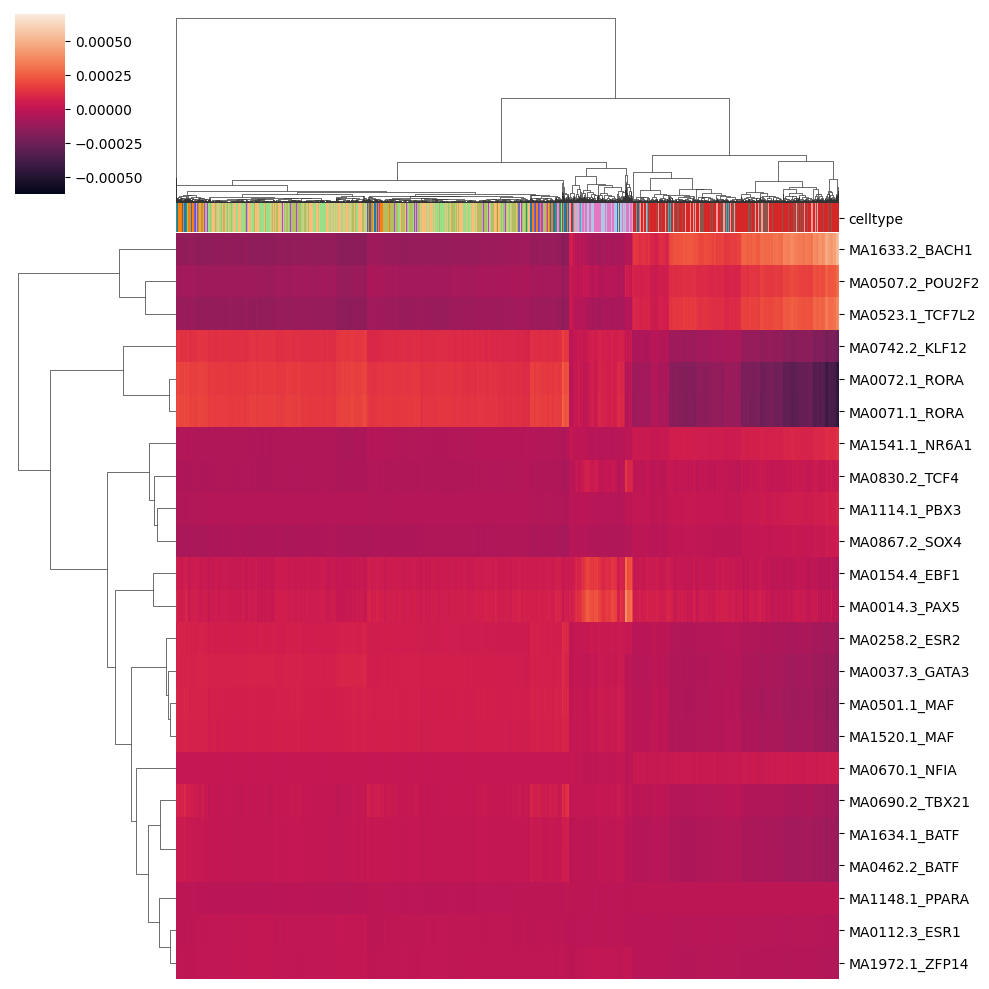

In [30]:
import seaborn as sns 
cmap = dict(zip(ad_rna.obs["celltype"].cat.categories, ad_rna.uns['celltype_colors']))
col_colors = ad_rna_subset.obs['celltype'].map(cmap)
tf_act_df = pd.DataFrame(tf_act_raw.T, 
                         columns=jaspar_motifs['motif']+"_"+jaspar_motifs['tf'], 
                         index=ad_rna_subset.obs.index,)
cm = sns.clustermap(tf_act_df.T, col_colors=col_colors, xticklabels=False,
               )